2. Classification using Deep neural network Binary classification using Deep Neural Networks Example: Classify movie reviews into 
positive" reviews and "negative" reviews, just based on the text content of the reviews. 
Use IMDB dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer


In [11]:
# Load dataset
data = pd.read_csv(r"D:\TE-Computer\sem VII\DL\IMDB_Dataset.csv", encoding='latin-1', on_bad_lines='skip')

In [3]:
# Convert text → numbers
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['review'])
y = data['sentiment'].map({'positive': 1, 'negative': 0})
print("Sentiment Count:")
print(data['sentiment'].value_counts())


Sentiment Count:
sentiment
negative                                                                                                   24824
positive                                                                                                   24815
 I did buy this film for my own video library!). I adored the little boy who played the 'Golden Child'         1
Name: count, dtype: int64


In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# Model
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(5000,)),
    keras.layers.Dense(1, activation='sigmoid')
])


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,033 (312.63 KB)

 Trainable params: 80,033 (312.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train
# Sort indices for sparse matrices to avoid TensorFlow error
X_train.sort_indices()
X_test.sort_indices()

history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
993/993 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7599 - loss: nan - val_accuracy: 0.5003 - val_loss: nan
Epoch 2/5
993/993 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4993 - loss: nan - val_accuracy: 0.5003 - val_loss: nan
Epoch 3/5
993/993 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4993 - loss: nan - val_accuracy: 0.5003 - val_loss: nan
Epoch 4/5
993/993 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4993 - loss: nan - val_accuracy: 0.5003 - val_loss: nan
Epoch 5/5
993/993 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4993 - loss: nan - val_accuracy: 0.5003 - val_loss: nan


In [8]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5022 - loss: nan
Accuracy: 0.5021653771400452


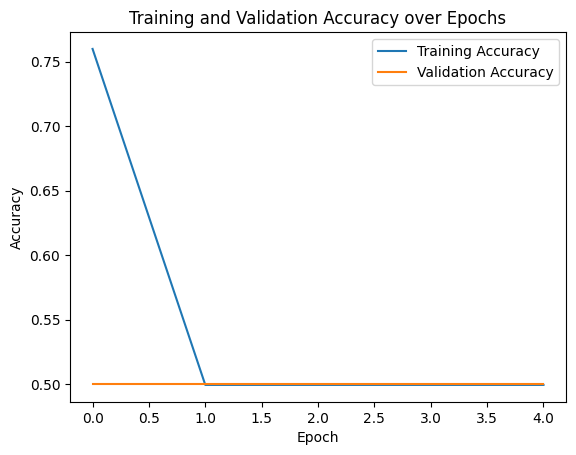

In [10]:
# Graphs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.title("Training and Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()